# FASTA Utilities — Demo Notebook

This notebook demonstrates the usage of `fasta_utils.py`, a bioinformatics utility toolkit for:
- FASTA file processing (splitting, filtering, renaming, counting)
- Protein localization analysis against a genome-scale metabolic model

**Dependencies:** `biopython`, `pandas`, `numpy`

```bash
pip install biopython pandas numpy
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO

from fasta_utils import (
    split_fasta,
    filter_hypothetical_proteins,
    count_sequences,
    rename_sequences,
    load_localization_data,
    map_genes_to_model,
    compare_localizations
)

---
## 1. FASTA File Processing

### 1.1 Count sequences
Before processing, check how many sequences are in the file.

In [2]:
# Replace with your FASTA file path
FASTA_FILE = "Egrandis_proteins.faa"

total = count_sequences(FASTA_FILE)

45101 sequences in Egrandis_proteins.faa


### 1.2 Split a large FASTA file
Large FASTA files often need to be split for tools with sequence limits (e.g. NCBI BLAST has a 100k sequence cap per submission).

In [3]:
num_files = split_fasta(
    file_in=FASTA_FILE,
    file_out="proteome_batch",
    batch_size=10000
)

print(f"Created {num_files} split files")

Wrote 10000 records to proteome_batch_split_1.fasta
Wrote 10000 records to proteome_batch_split_2.fasta
Wrote 10000 records to proteome_batch_split_3.fasta
Wrote 10000 records to proteome_batch_split_4.fasta
Wrote 5101 records to proteome_batch_split_5.fasta
Created 5 split files


### 1.3 Filter hypothetical / unknown proteins
Hypothetical proteins are unannotated sequences. Separating them is useful for downstream annotation pipelines.

In [4]:
hypo_count = filter_hypothetical_proteins(
    file_in=FASTA_FILE,
    file_out="hypothetical_proteins.fasta",
    keyword="uncharacterized protein"
)

annotated_count = total - hypo_count
print(f"Annotated: {annotated_count} | Hypothetical: {hypo_count}")

7735 sequences matching 'uncharacterized protein' written to hypothetical_proteins.fasta
Annotated: 37366 | Hypothetical: 7735


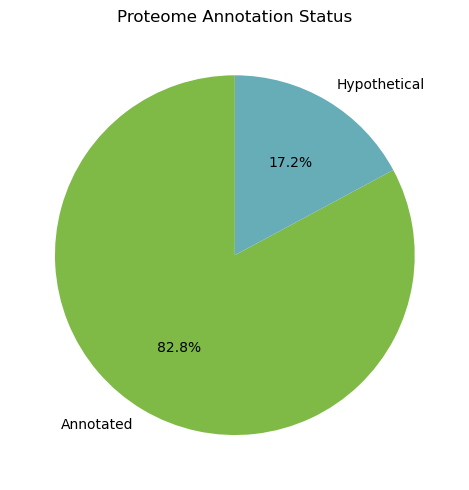

In [6]:
# Visualise annotated vs hypothetical protein breakdown
labels = ["Annotated", "Hypothetical"]
sizes = [annotated_count, hypo_count]
colors = ["#7eba45", "#67adb8"]

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
ax.set_title("Proteome Annotation Status")
plt.tight_layout()
plt.savefig("annotation_status.png", dpi=150)
plt.show()

### 1.4 Rename sequence IDs
Standardising IDs to a short prefix + index is required by many bioinformatics tools that reject long or special-character headers.

In [7]:
rename_sequences(
    file_in=FASTA_FILE,
    file_out="proteome_renamed.fasta",
    prefix="PROT",
    dict_out="fasta_dictionary.xlsx"
)

# Preview the mapping dictionary
mapping = pd.read_csv("fasta_dictionary.xlsx", sep="\t", header=None, names=["Original_ID", "New_ID"])
print(f"Total renamed: {len(mapping)}")
mapping.head(10)

Renamed 45101 sequences. Dictionary saved to fasta_dictionary.xlsx
Total renamed: 45101


,Original_ID,New_ID
0,NP_001289637.1 MADS-box protein JOINTLESS [Euc...,PROT00001
1,NP_001289638.1 tubulin beta-9 chain [Eucalyptu...,PROT00002
2,NP_001289639.1 glycogen debranching enzyme [Eu...,PROT00003
3,NP_001289640.1 calcineurin subunit B [Eucalypt...,PROT00004
4,NP_001289641.1 iron-sulfur cluster assembly pr...,PROT00005
5,NP_001289642.1 developmental protein SEPALLATA...,PROT00006
6,NP_001289643.1 UDP-glucuronic acid decarboxyla...,PROT00007
7,NP_001289644.1 cellulose synthase A catalytic ...,PROT00008
8,NP_001289645.1 cellulose synthase A catalytic ...,PROT00009
9,NP_001289646.1 inositol oxygenase [Eucalyptus ...,PROT00010


---
## 2. Protein Localization Analysis

This section cross-references predicted protein subcellular localizations against the compartment assignments of reactions in a genome-scale metabolic model (GEM).

Mismatches between predicted protein location and reaction location may indicate:
- Errors in model compartment assignments
- Proteins with multiple localization signals
- Candidates for model curation

### 2.1 Load data

In [8]:
# Replace with your file paths
MODEL_FILE = "model.xlsx"
LOCALIZATION_FILE = "localization_info.xlsx"

reactions_df, localization_df = load_localization_data(MODEL_FILE, LOCALIZATION_FILE)

print(f"Reactions loaded:  {len(reactions_df)}")
print(f"Proteins loaded:   {len(localization_df)}")
reactions_df.tail()

Reactions loaded:  2294
Proteins loaded:   18831


,Abbreviation,Gene,GPR,Reaction Location
2289,PHCDb,Duns09671,,Cytoplasm
2290,EHGLAT,,,Cytoplasm
2291,PHCHGS,,,Cytoplasm
2292,4HGLSD,Duns09671,,Cytoplasm
2293,DDPGA,Duns14438,,Cytoplasm


### 2.2 Map proteins to model reactions

In [9]:
localization_df = map_genes_to_model(reactions_df, localization_df)

# Summary
in_model = localization_df["In_Model"].value_counts()
print(f"Proteins in model:     {in_model.get('Y', 0)}")
print(f"Proteins not in model: {in_model.get('N', 0)}")
localization_df.head(10)

Total Protein-Reaction matches: 2916
Proteins in model:     928
Proteins not in model: 17903


,Protein ID,Predicted Localization,In_Model,Reaction_Count
0,Duns00001,Cytoplasm,N,0
1,Duns00002,Lysosome/Vacuole,N,0
2,Duns00003,Cytoplasm|Nucleus,N,0
3,Duns00004,Cytoplasm,N,0
4,Duns00005,Cytoplasm,N,0
5,Duns00006,Cytoplasm,N,0
6,Duns00007,Cytoplasm|Nucleus,N,0
7,Duns00008,Nucleus,N,0
8,Duns00009,Extracellular,N,0
9,Duns00010,Cytoplasm,N,0


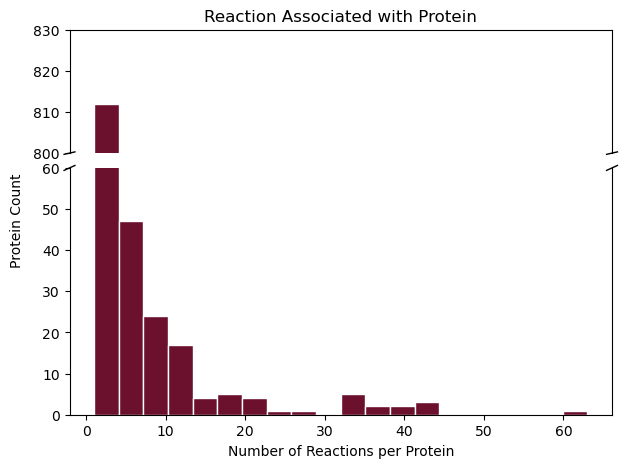

In [10]:
# Distribution of reactions per protein
in_model_only = localization_df[localization_df["In_Model"] == "Y"]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                                      gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.08})

# Plot histogram on both axes
for ax in (ax_top, ax_bot):
    ax.hist(in_model_only["Reaction_Count"], bins=20, color="#6b102d", edgecolor="white")

# Set y-limits for each panel
ax_top.set_ylim(800, 830)   # upper panel: shows the tall bar
ax_bot.set_ylim(0, 60)     # lower panel: shows the small bars

# Hide the spines between axes
ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)
ax_top.tick_params(bottom=False)

# Add diagonal break marks
d = 0.01  # size of diagonal lines
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Labels
ax_bot.set_xlabel("Number of Reactions per Protein")
fig.text(0.04, 0.5, "Protein Count", va='center', rotation='vertical')
ax_top.set_title("Reaction Associated with Protein")


plt.savefig("reaction_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Compare predicted vs. model localizations

In [11]:
full_df, mismatch_df = compare_localizations(reactions_df, localization_df)

match_rate = full_df["Localization_Match"].mean() * 100
print(f"Localization match rate: {match_rate:.1f}%")
full_df.head(10)

Total pairs: 2916 | Mismatches: 1787
Localization match rate: 38.7%


,Protein_ID,Rxn_Abbreviation,Reaction_Location,Protein_Location,Localization_Match
0,Duns00031,G3PL,Chloroplast,Chloroplast,True
1,Duns00205,DOLDPP,Cytoplasm,Endoplasmic reticulum,False
2,Duns00205,DEDOLDPS,Cytoplasm,Endoplasmic reticulum,False
3,Duns00254,PPC,Cytoplasm,Cytoplasm,True
4,Duns00282,MTMOHT,Mitochondrion,Cytoplasm,False
5,Duns00293,GCL,Chloroplast,Cytoplasm|Nucleus,False
6,Duns00424,UGE,Cytoplasm,Extracellular,False
7,Duns00499,PPNDH,Cytoplasm,Mitochondrion,False
8,Duns00510,TMDPK,Cytoplasm,Cytoplasm|Nucleus,True
9,Duns00565,CPP3O,Chloroplast,Cytoplasm,False


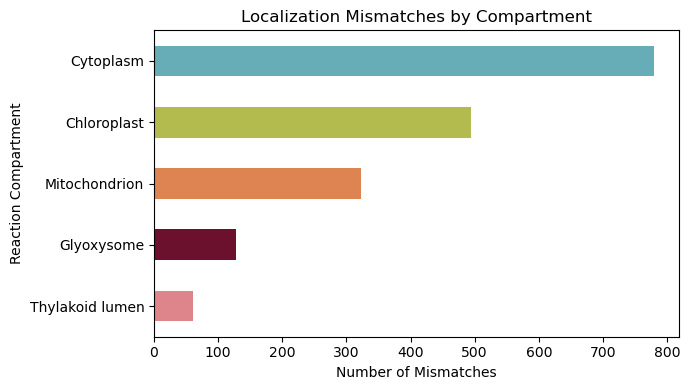

In [12]:
# Breakdown of mismatches by reaction compartment
mismatch_counts = (
    mismatch_df.groupby("Reaction_Location")
    .size()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 4))
mismatch_counts.plot(kind="barh", ax=ax, color=["#de858b","#6b102d","#dd8452","#b3ba4e","#67adb8"])
ax.set_xlabel("Number of Mismatches")
ax.set_ylabel("Reaction Compartment")
ax.set_title("Localization Mismatches by Compartment")
plt.tight_layout()
plt.savefig("mismatch_by_compartment.png", dpi=150)
plt.show()

### 2.4 Export results

In [13]:
localization_df.to_excel("gene_model_mapping.xlsx", index=False)
mismatch_df.to_excel("localization_mismatches.xlsx", index=False)

print("Results saved.")
print(f"  gene_model_mapping.xlsx     — {len(localization_df)} proteins")
print(f"  localization_mismatches.xlsx — {len(mismatch_df)} mismatched pairs")

Results saved.
  gene_model_mapping.xlsx     — 18831 proteins
  localization_mismatches.xlsx — 1787 mismatched pairs


---
## Summary

| Step | Output |
|---|---|
| Count sequences | Total sequence count |
| Split FASTA | Batch files ready for BLAST submission |
| Filter hypothetical | Separated unannotated sequences |
| Rename IDs | Standardised headers + mapping dictionary |
| Map to model | Proteins flagged with reaction associations |
| Compare localizations | Mismatch candidates for model curation |